In [2]:
import numpy as np

import sys
import os
import warnings

warnings.simplefilter("ignore", FutureWarning)

In [3]:
from attack_training import optimize, compute_loss

# Add the ability to import modules from the ocr/utils directory
sys.path.append(os.path.abspath("../utils"))

from google_vision import query_google_vision, predict_and_annotate
from image_tools import show_image, render_text


In [ ]:
def render_function(text, params):
    FONT_PATH = '../resources/fonts/zxx-noise.ttf'
    CANVAS_SIZE = (1200, 300)

    p = {
        "text_color": (255, 255, 255),
        "background_color": (0, 0, 0)
    }

    p.update(params)
    return render_text(text, params=p, font_path=FONT_PATH, canvas_size=CANVAS_SIZE)

def loss_function(pred_text, truth_text, symbol_confs, word_count):
    ALPHA = 0.0 # strength of confidence term
    BETA = 1.5  # strenght of edit distance term
    GAMMA = 0.75 # strength of detection term

    return compute_loss(pred_text, truth_text, symbol_confs, word_count, alpha=ALPHA, beta=BETA, gamma=GAMMA)

def theta_to_params(theta):
    return {
        "per_char_rot_std": np.clip(abs(theta[0])*10, 0, 20),
        "kerning_std": np.clip(theta[1]*6, -12, 12),
        "baseline_amp": np.clip(theta[2]*10, 0, 10),
        "baseline_freq": np.clip(theta[3]*5, 1, 10),
        "y_jitter_std": np.clip(theta[4]*5, 0, 10)
    }

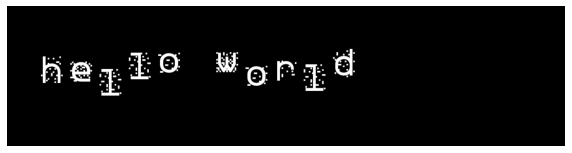

In [27]:
p = {
    "per_char_rot_std": 0.0,
    "kerning_std": 0,
    "baseline_amp": 10.0,
    "baseline_freq": 10.0,
    "y_jitter_std": 20.0,
}

show_image(render_function("hello world", params=p))

In [28]:
theta = np.array([
    1.0,  # per_char_rot_std
    1.0,  # kerning_std
    1.0,  # baseline_amp
    1.0,  # baseline_freq
    1.0,  # y_jitter_std
])

In [29]:
test_labels = ['the quick brown', 'fox jumped over', 'the lazy dog',
               'hello world', 'computer and data', 'privacy']

theta = optimize(theta,
                 test_labels,
                 
                 query_function=query_google_vision,
                 loss_function=loss_function,
                 rendering_function=render_function,
                 param_mapping_function=theta_to_params,

                 steps=100,
                 sigma=1,
                 lr=0.7,
                 n_samples=40
                )

Step 000 | Loss: 0.9332 | Theta: [0.94930271 0.97207601 1.04473407 0.87038885 0.85624478]
Step 001 | Loss: 0.9435 | Theta: [0.92602763 0.70696134 0.94661278 0.88268979 0.81720778]
Step 002 | Loss: 0.9302 | Theta: [0.92554975 0.6635     0.85968611 0.88147072 0.76851014]
Step 003 | Loss: 0.9472 | Theta: [0.79183654 0.6053133  0.79552971 0.8117353  0.83902436]
Step 004 | Loss: 0.9345 | Theta: [0.71492564 0.58989049 0.67175893 0.94201267 0.88880631]
Step 005 | Loss: 0.9343 | Theta: [0.80584844 0.54933721 0.79295871 0.87946467 0.8374365 ]
Step 006 | Loss: 0.9343 | Theta: [0.76923778 0.51638305 0.85565651 0.86909475 0.94177357]
Step 007 | Loss: 0.9346 | Theta: [0.8468019  0.54815215 1.00443377 0.86007554 1.05749558]
Step 008 | Loss: 0.9270 | Theta: [0.86088179 0.70162115 0.94017301 0.67591098 1.15721226]
Step 009 | Loss: 0.9366 | Theta: [0.92028102 0.67939252 0.85158469 0.70663513 1.12759673]
Step 010 | Loss: 0.9569 | Theta: [0.77787546 0.7071192  0.92072664 0.71897149 0.97263699]
Step 011 |

In [30]:
theta_to_params(theta)

{'per_char_rot_std': 5.148211689982871,
 'kerning_std': 2.596301353150507,
 'baseline_amp': 8.938597084084268,
 'baseline_freq': 1.0,
 'y_jitter_std': 9.747951384353103}

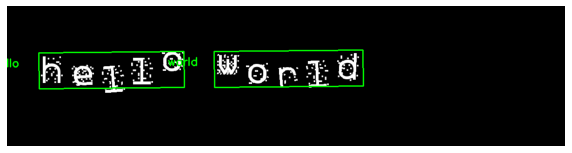

{'text': 'hello world',
 'symbol_confs': [0.9262584447860718,
  0.9743639230728149,
  0.9197301864624023,
  0.9400942921638489,
  0.8173102140426636,
  0.8753681778907776,
  0.938096284866333,
  0.9117650389671326,
  0.9713882207870483,
  0.9582615494728088],
 'word_count': 2}

In [31]:
img = render_function("hello world", params=theta_to_params(theta))
show_image(predict_and_annotate(img))
query_google_vision(img)

In [32]:
validation_labels = [
    "quick brown fox",
    "lazy jumping dog",
    "quiet valley breeze",
    "bright silver moon",
    "jovial wizard",
    "crisp autumn wind",
    "heavy black quartz",
    "zesty lemon cake",
    "vivid jungle path",
    "broken clay pot",
    "gentle river bank",
    "frozen lake shore",
    "simple wooden box",
    "tiny blue cabin",
    "wild forest trail",
    "fresh baked bread",
    "calm ocean wave",
    "dusty gravel road",
    "sharp kitchen knife",
    "glowing amber light",
    "noisy market square",
    "proud royal knight",
    "rapid silver train",
    "golden wheat field",
    "ancient stone wall",
    "steady drum beat",
    "clear night sky",
    "quiet zebra grazing",
    "brisk mountain air",
    "young clever mind"
]

for label in validation_labels:
    img = render_function(label, params=theta_to_params(theta))
    out_text = query_google_vision(img)['text']

    status = '[ ]'
    if label == out_text:
        status = '[+]'

    print(f"{status} | {repr(label)} --> {repr(out_text)}")

[ ] | 'quick brown fox' --> 'Quick brown fox'
[+] | 'lazy jumping dog' --> 'lazy jumping dog'
[ ] | 'quiet valley breeze' --> 'quiet Valley breez'
[ ] | 'bright silver moon' --> '74\nbright\nsilver\nmoon'
[ ] | 'jovial wizard' --> 'Jovial wizard'
[ ] | 'crisp autumn wind' --> 'DUT\nUunine ds t u o'
[+] | 'heavy black quartz' --> 'heavy black quartz'
[ ] | 'zesty lemon cake' --> 'Zesty lemon Cake\nU'
[ ] | 'vivid jungle path' --> 'yed ǝt bunţ PIATA'
[+] | 'broken clay pot' --> 'broken clay pot'
[ ] | 'gentle river bank' --> 'gentle\nriver bank'
[ ] | 'frozen lake shore' --> 'frozen\nlake Shore'
[ ] | 'simple wooden box' --> 'imple\nuapoom\nbox'
[+] | 'tiny blue cabin' --> 'tiny blue cabin'
[+] | 'wild forest trail' --> 'wild forest trail'
[+] | 'fresh baked bread' --> 'fresh baked bread'
[ ] | 'calm ocean wave' --> 'Uesso'
[ ] | 'dusty gravel road' --> 'dusty gravel\nroad'
[ ] | 'sharp kitchen knife' --> 'Sharp Kitchen'
[ ] | 'glowing amber light' --> 'ligh\n紅'
[ ] | 'noisy market squar